In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding,Dense
from tensorflow.keras import Sequential
from sklearn.metrics import r2_score
import pandas as pd
import keras
from keras import backend as K
print(tf.__version__)

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.15.0


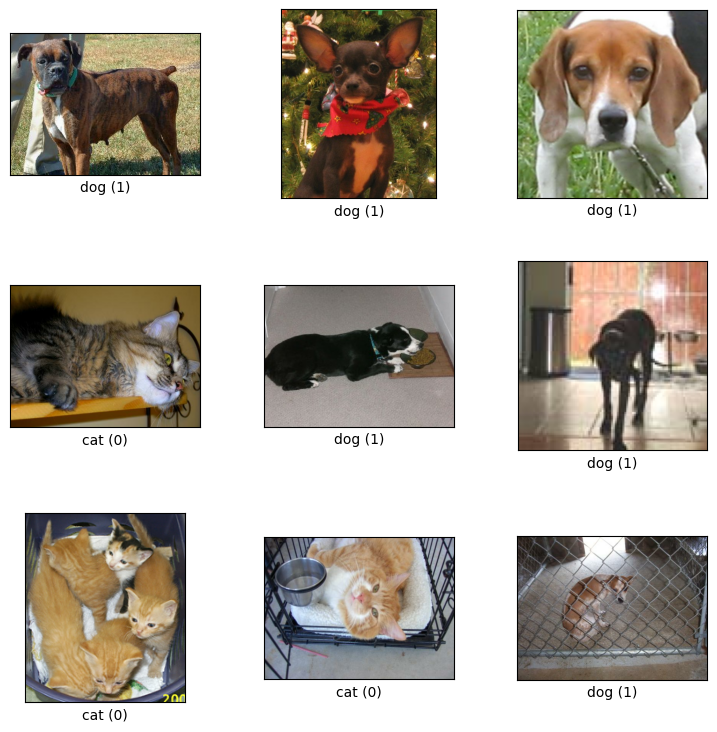

In [2]:
(ds_train_mnist, ds_test_mnist), ds_info = tfds.load(
    name = 'cats_vs_dogs',
    split=['train[:20%]', 'train[20%:30%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True)
fig = tfds.show_examples(ds_train_mnist, ds_info)

In [96]:
label_names = ds_info.features['label'].names
label_names

['cat', 'dog']

In [97]:
ds_train_mnist

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [156]:
def augment_data(images, labels):
    images = tf.image.resize(images,(224,224))
    images = tf.image.random_flip_left_right(images)
    images = tf.image.random_flip_up_down(images)
    images = tf.image.random_brightness(images, 0.2)
    images = tf.image.random_contrast(images, 0.5, 2.0)
    images = tf.image.random_saturation(images, 0.75, 1.25)
    return tf.cast(images, tf.float32)/255., tf.one_hot(labels,2)

def augment_dataTL(images, labels):
    images = tf.image.resize(images,(224,224))
    return tf.cast(images, tf.float32), tf.one_hot(labels,2)


def data_load(data_ds,augmented=augment_data,shuffle_=True ,batch_=5):
    data_ds = data_ds.map(
        augmented, num_parallel_calls=tf.data.AUTOTUNE)
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

In [157]:
data_train = data_load(ds_train_mnist)
data_test = data_load(ds_test_mnist,shuffle_=False)
for ds,lb in data_train.take(1):
    shaped=list(ds.shape)
shaped

[5, 224, 224, 3]

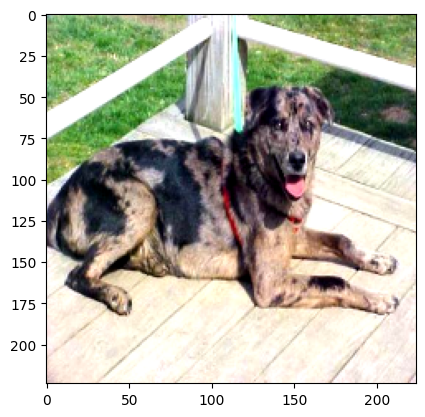

In [158]:
plt.imshow(ds[0].numpy())

In [159]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=shaped[1:]),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(2,activation='softmax')
])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 150528)            0         
                                                                 
 dense_6 (Dense)             (None, 64)                9633856   
                                                                 
 dense_7 (Dense)             (None, 2)                 130       
                                                                 
Total params: 9633986 (36.75 MB)
Trainable params: 9633986 (36.75 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [160]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'])

In [161]:
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min")
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min' ,factor=0.4,
                              patience=5, min_lr=1e-7,verbose=1)
directory_files='carpeta_resultados_clase/'
def scheduler(epoch, lr):
      if epoch%10 != 0:
        return lr
      else:
        return lr * tf.math.exp(-0.1)
callback_Scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler,verbose=1)

checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=directory_files+'model.{epoch:02d}-{val_loss:.2f}.h5',
                                               verbose=1,
                                               save_best_only=True)
tensorboard =tf.keras.callbacks.TensorBoard(log_dir=directory_files+'logs', histogram_freq=1),

callbacks=[tensorboard, checkpoint,early_callback,callback_Scheduler]


history= model.fit(
    data_train,
    epochs=6,
    validation_data=data_test,
    callbacks=callbacks,
    verbose=1)


Epoch 1: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 1/6
160/931 [====>.........................] - ETA: 1:07 - loss: 18.2235 - accuracy: 0.5038

KeyboardInterrupt: 

In [32]:
model.evaluate(data_test)

466/466 [==============================] - 2s 3ms/step - loss: 0.6928 - accuracy: 0.5105


[0.6927893161773682, 0.510528564453125]

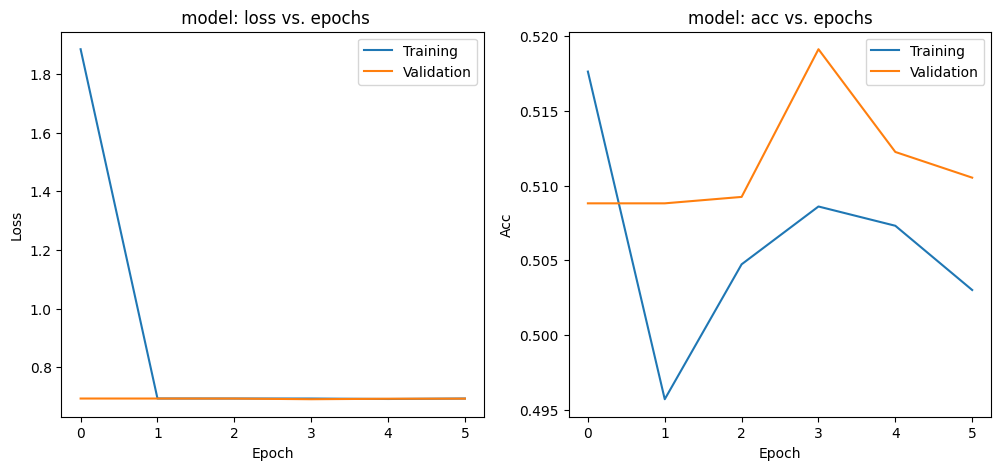

In [33]:
fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title(' model: loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs. epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

In [34]:
def show_confusion_matrix(cm, labels):
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, xticklabels=labels, yticklabels=labels, 
              annot=True, fmt='g')
  plt.xlabel('Prediction')
  plt.ylabel('Label')
  plt.show()

1/1 [==============================] - 0s 26ms/step


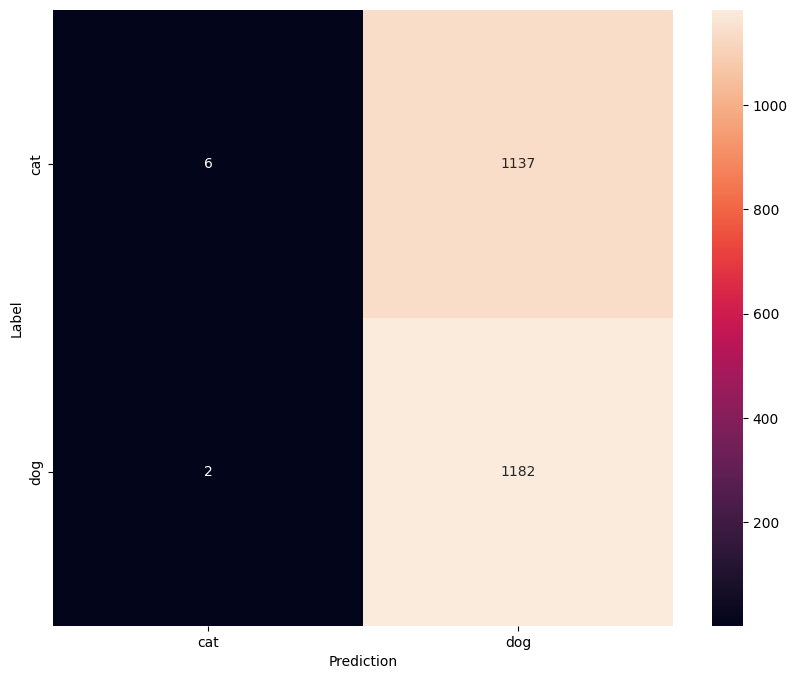

In [35]:
pred=[]
lab=[]
for ds, lb in data_test:
    pred.append(tf.math.argmax(model.predict(ds),axis=1))
    lab.append(lb)
confusion_mtx = tf.math.confusion_matrix(
    np.concatenate(lab),
    np.concatenate(pred),
    num_classes=len(label_names))
show_confusion_matrix(confusion_mtx, label_names)

In [38]:
shaped

[5, 128, 128, 3]

In [162]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dropout,Dense
modelcnn = Sequential()
modelcnn.add(Conv2D(16,activation='relu' , strides=(1, 1),kernel_size=(5,5),padding='same', input_shape=shaped[1:]))
modelcnn.add(MaxPooling2D(pool_size=(2, 2)))
modelcnn.add(Conv2D(32,activation='relu',  strides=(1, 1),kernel_size=(3,3),padding='same'))
modelcnn.add(MaxPooling2D(pool_size=(2, 2)))
modelcnn.add(Conv2D(32,activation='relu',  strides=(1, 1),kernel_size=(3,3),padding='same'))
modelcnn.add(MaxPooling2D(pool_size=(2, 2)))

# Flattening the 2D arrays for fully connected layers
modelcnn.add(Flatten()) 
#modelcnn.add(tf.keras.layers.GlobalAveragePooling2D())
modelcnn.add(Dense(128, activation=tf.nn.relu))
modelcnn.add(Dropout(0.2))
modelcnn.add(Dense(2,activation=tf.nn.softmax))
modelcnn.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 16)      1216      
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 28, 28, 32)       

In [163]:
modelcnn.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy'])

In [164]:
directory_files='carpeta_resultados_clasecnn/'

In [165]:

early_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min")
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min' ,factor=0.4,
                              patience=5, min_lr=1e-7,verbose=1)

def scheduler(epoch, lr):
      if epoch%10 != 0:
        return lr
      else:
        return lr * tf.math.exp(-0.1)
callback_Scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler,verbose=1)

checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=directory_files+'model.{epoch:02d}-{val_loss:.2f}.h5',
                                               verbose=1,
                                               save_best_only=True)
tensorboard =tf.keras.callbacks.TensorBoard(log_dir=directory_files+'logs', histogram_freq=1),

callbacks=[tensorboard, checkpoint,early_callback,callback_Scheduler]


historycnn= modelcnn.fit(
    data_train,
    epochs=2,
    validation_data=data_test,
    callbacks=callbacks,
    verbose=1)


Epoch 1: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 1/2


 53/931 [>.............................] - ETA: 55s - loss: 0.7252 - accuracy: 0.5132

KeyboardInterrupt: 

In [42]:
modelcnn.evaluate(data_test)

466/466 [==============================] - 2s 5ms/step - loss: 0.6664 - accuracy: 0.6038


[0.6663950681686401, 0.6037817001342773]

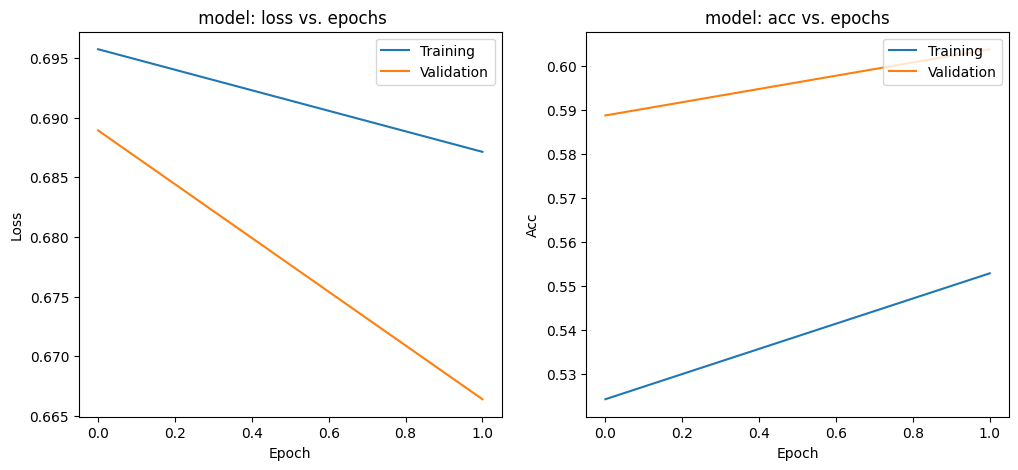

In [43]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(historycnn.history['loss'])
plt.plot(historycnn.history['val_loss'])
plt.title(' model: loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(historycnn.history['accuracy'])
plt.plot(historycnn.history['val_accuracy'])
plt.title('model: acc vs. epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

(<matplotlib.image.AxesImage at 0x1b31a99c310>,
 <tf.Tensor: shape=(), dtype=int64, numpy=0>)

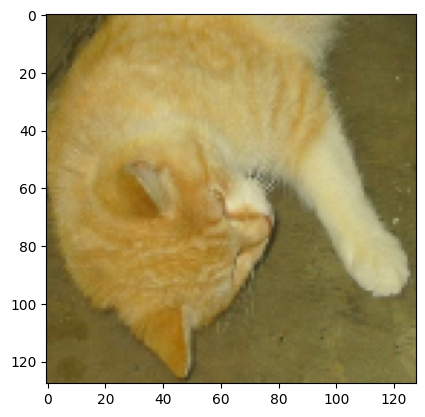

In [44]:
plt.imshow(ds[0]),lb[0]

In [45]:
successive_outputs = [layer.output for layer in modelcnn.layers[1:]]
visualization_model = tf.keras.models.Model(inputs = modelcnn.input, outputs = successive_outputs)

In [46]:
successive_feature_maps = visualization_model.predict(tf.expand_dims(ds[0],axis=0))

1/1 [==============================] - 0s 104ms/step


In [47]:
layer_names = [layer.name for layer in modelcnn.layers]

(1, 64, 64, 16)
(1, 64, 64, 32)
(1, 32, 32, 32)
(1, 32, 32, 32)
(1, 16, 16, 32)
(1, 8192)
(1, 128)
(1, 128)
(1, 2)


C:\Users\javier\AppData\Local\Temp\ipykernel_11276\2756211480.py:20: RuntimeWarning: invalid value encountered in divide
  x /= x.std ()
C:\Users\javier\AppData\Local\Temp\ipykernel_11276\2756211480.py:23: RuntimeWarning: invalid value encountered in cast
  x  = np.clip(x, 0, 255).astype('uint8')


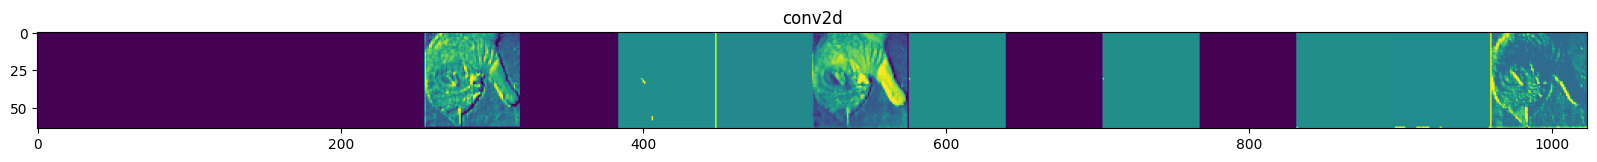

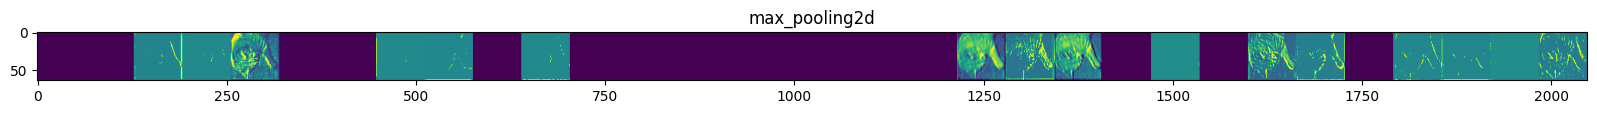

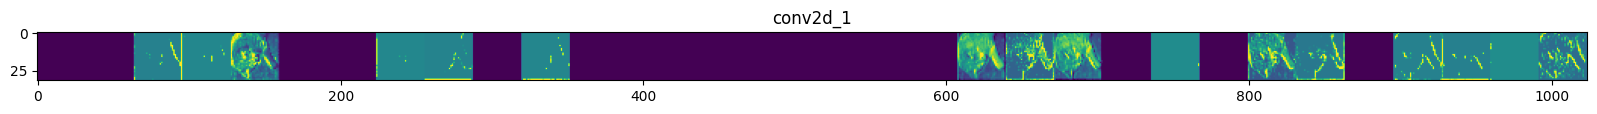

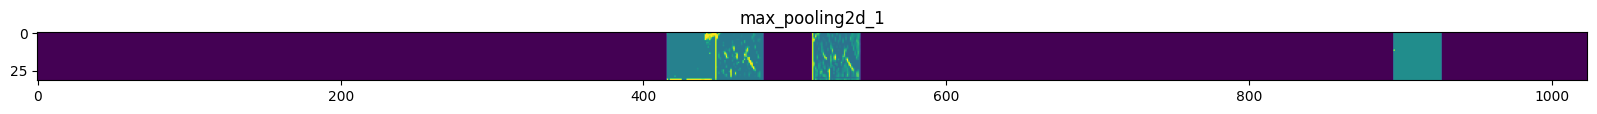

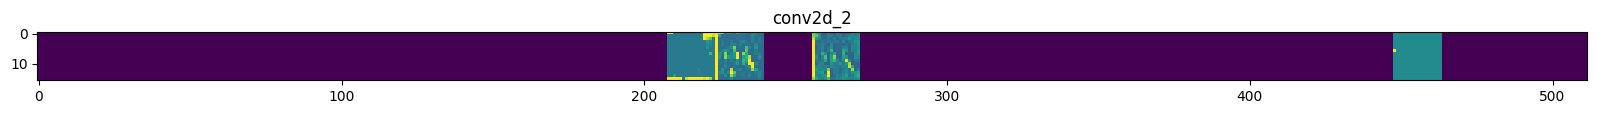

In [48]:
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  print(feature_map.shape)
  if len(feature_map.shape) == 4:
    
    #-------------------------------------------
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    #-------------------------------------------
    n_features = feature_map.shape[-1]  # number of features in the feature map
    size       = feature_map.shape[ 1]  # feature map shape (1, size, size, n_features)
    
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    
    #-------------------------------------------------
    # Postprocess the feature to be visually palatable
    #-------------------------------------------------
    for i in range(n_features):
      x  = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std ()
      x *=  64
      x += 128
      x  = np.clip(x, 0, 255).astype('uint8')
      display_grid[:, i * size : (i + 1) * size] = x # Tile each filter into a horizontal grid

    #-----------------
    # Display the grid
    #-----------------

    scale = 20. / n_features
    plt.figure( figsize=(scale * n_features, scale) )
    plt.title ( layer_name )
    plt.grid  ( False )
    plt.imshow( display_grid, aspect='auto', cmap='viridis' ) 

In [49]:
df = pd.read_csv('Sunspots_.csv', index_col=0)
df.head()

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7


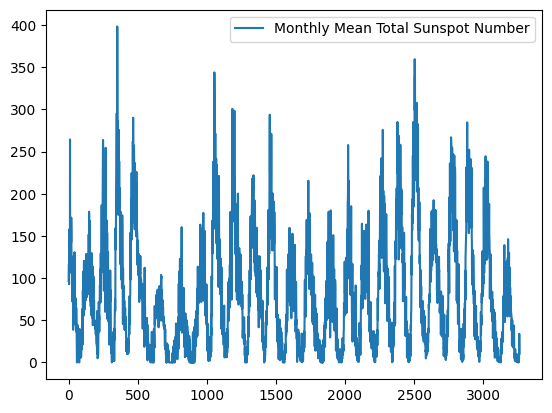

In [36]:
df.plot()
plt.show()

In [37]:
time_index = np.array(df['Date'])
data = np.array(df['Monthly Mean Total Sunspot Number'])
print(time_index.shape)
print(data.shape)

(3265,)
(3265,)


In [38]:
##Hiperparametros
SPLIT_TEST_TRAIN = 0.8
WINDOW_SIZE = 60
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

In [39]:
split_index = int(SPLIT_TEST_TRAIN * data.shape[0])
print(split_index)

2612


In [40]:
train_data = data[:split_index]
train_time = time_index[:split_index]

test_data = data[split_index:]
test_time = time_index[split_index:]

In [41]:
def ts_data_timeseries(data, window_size, batch_size):
  
  ds = tf.data.Dataset.from_tensor_slices(data)
  ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda window: window.batch(window_size + 1))
  ds = ds.map(lambda window: (window[:-1], window[-1]))
  ds = ds.batch(batch_size).prefetch(1)
  return ds



In [42]:
train_dataset = ts_data_timeseries(train_data, WINDOW_SIZE, BATCH_SIZE)
test_dataset = ts_data_timeseries(test_data, WINDOW_SIZE, BATCH_SIZE)

In [43]:
 for ds in train_dataset.take(1):
        print(ds)

(<tf.Tensor: shape=(32, 60), dtype=float64, numpy=
array([[ 96.7, 104.3, 116.7, ...,  41.7,  33.3,  11.2],
       [104.3, 116.7,  92.8, ...,  33.3,  11.2,   0. ],
       [116.7,  92.8, 141.7, ...,  11.2,   0. ,   5. ],
       ...,
       [ 84.5, 110.5,  99.7, ...,   9. ,  15.7,  20.8],
       [110.5,  99.7,  39.2, ...,  15.7,  20.8,  21.5],
       [ 99.7,  39.2,  38.7, ...,  20.8,  21.5,   6. ]])>, <tf.Tensor: shape=(32,), dtype=float64, numpy=
array([ 0. ,  5. ,  2.8, 22.8, 34.5, 44.5, 31.3, 20.5, 13.7, 40.2, 22. ,
        7. , 17. , 18.7, 11.3, 10.8,  0. ,  0. , 14.3,  5.3, 29.7, 39.5,
       11.3, 33.3, 20.8, 11.8,  9. , 15.7, 20.8, 21.5,  6. , 10.7])>)


In [51]:
def plots_pred(model, data, test_data, conv=True):
    forecast=[]
    for time in range(split_index-WINDOW_SIZE,len(data) - WINDOW_SIZE):
      forecast.append(model.predict(data[time:time + WINDOW_SIZE][np.newaxis]))

    forecast = forecast[:]
    results = np.array(forecast)[:, 0, 0]
    if conv:
        results= np.squeeze(results)

    error_test = tf.keras.metrics.mean_absolute_error(test_data, results).numpy()
    plt.figure(figsize=(15, 6))

    plt.plot(list(range(split_index,len(data))), test_data, label = 'Test Data')
    plt.plot(list(range(split_index,len(data))), results, label = 'Predictions')
    plt.fill_between(range(split_index,len(data)), results - error_test, results + error_test, alpha = 0.3, color = 'grey',label=r'error 1-$\sigma$')
    plt.legend()
    plt.show()

In [52]:
modelcnn = keras.models.Sequential()
modelcnn.add(keras.layers.InputLayer(input_shape=[WINDOW_SIZE]))
modelcnn.add(keras.layers.Lambda(
       lambda inputs: tf.expand_dims(inputs,axis=0)))
for _ in range(3):
    modelcnn.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu"))
modelcnn.add(keras.layers.Conv1D(filters=1, kernel_size=1))
modelcnn.summary()
modelcnn.compile(loss="mse", optimizer="adam", metrics=['mse'])
historycnn = modelcnn.fit(train_dataset, epochs=20,
                    validation_data=test_dataset)


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda_3 (Lambda)           (1, None, 60)             0         
                                                                 
 conv1d_22 (Conv1D)          (1, None, 20)             2420      
                                                                 
 conv1d_23 (Conv1D)          (1, None, 20)             820       
                                                                 
 conv1d_24 (Conv1D)          (1, None, 20)             820       
                                                                 
 conv1d_25 (Conv1D)          (1, None, 1)              21        
                                                                 
Total params: 4081 (15.94 KB)
Trainable params: 4081 (15.94 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
80/80 [==

1/1 [==============================] - 0s 59ms/step


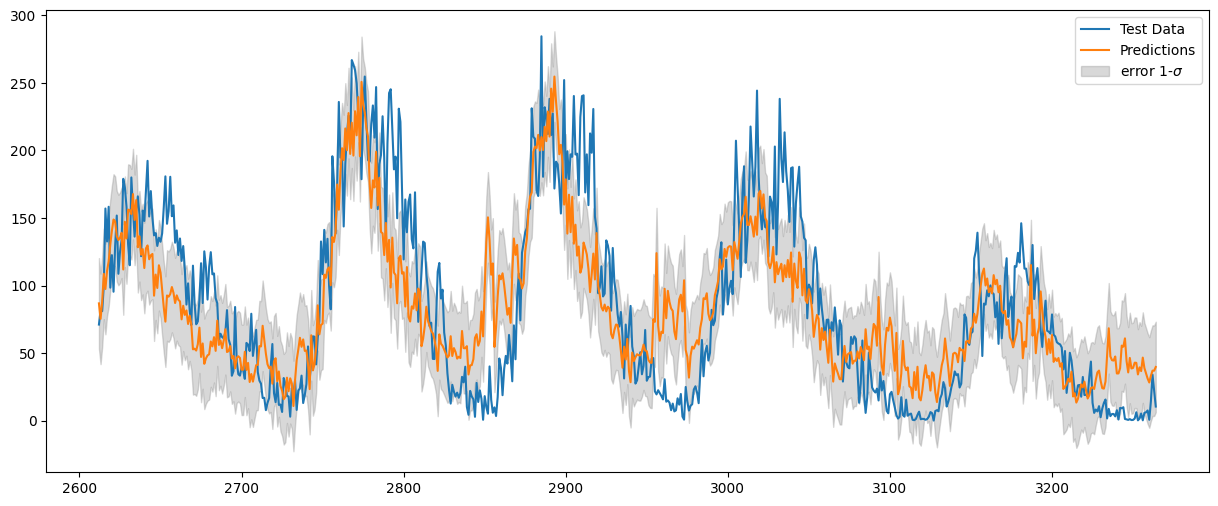

In [53]:
plots_pred(modelcnn, data, test_data)

In [54]:
modelwavelet = keras.models.Sequential()
modelwavelet.add(keras.layers.InputLayer(input_shape=[WINDOW_SIZE]))
modelwavelet.add(keras.layers.Lambda(
       lambda inputs: tf.expand_dims(inputs,axis=0)))
for rate in (1, 2, 4, 8) * 2:
    modelwavelet.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu", dilation_rate=rate))
modelwavelet.add(keras.layers.Conv1D(filters=1, kernel_size=1))
modelwavelet.compile(loss="mse", optimizer="adam", metrics=['mse'])
history = modelwavelet.fit(train_dataset, epochs=30,
                    validation_data=test_dataset)

Epoch 1/30
80/80 [==============================] - 6s 27ms/step - loss: 5780.2925 - mse: 5780.2925 - val_loss: 3106.3308 - val_mse: 3106.3308
Epoch 2/30
80/80 [==============================] - 1s 17ms/step - loss: 2425.1123 - mse: 2425.1123 - val_loss: 2074.1919 - val_mse: 2074.1919
Epoch 3/30
80/80 [==============================] - 2s 19ms/step - loss: 2097.3406 - mse: 2097.3406 - val_loss: 1898.6455 - val_mse: 1898.6455
Epoch 4/30
80/80 [==============================] - 1s 19ms/step - loss: 1943.6552 - mse: 1943.6552 - val_loss: 1799.1107 - val_mse: 1799.1107
Epoch 5/30
80/80 [==============================] - 1s 17ms/step - loss: 1884.9583 - mse: 1884.9583 - val_loss: 1780.7300 - val_mse: 1780.7300
Epoch 6/30
80/80 [==============================] - 2s 19ms/step - loss: 1821.4984 - mse: 1821.4984 - val_loss: 1720.4852 - val_mse: 1720.4852
Epoch 7/30
80/80 [==============================] - 1s 18ms/step - loss: 1790.4540 - mse: 1790.4540 - val_loss: 1670.5405 - val_mse: 1670.5405

1/1 [==============================] - 0s 53ms/step


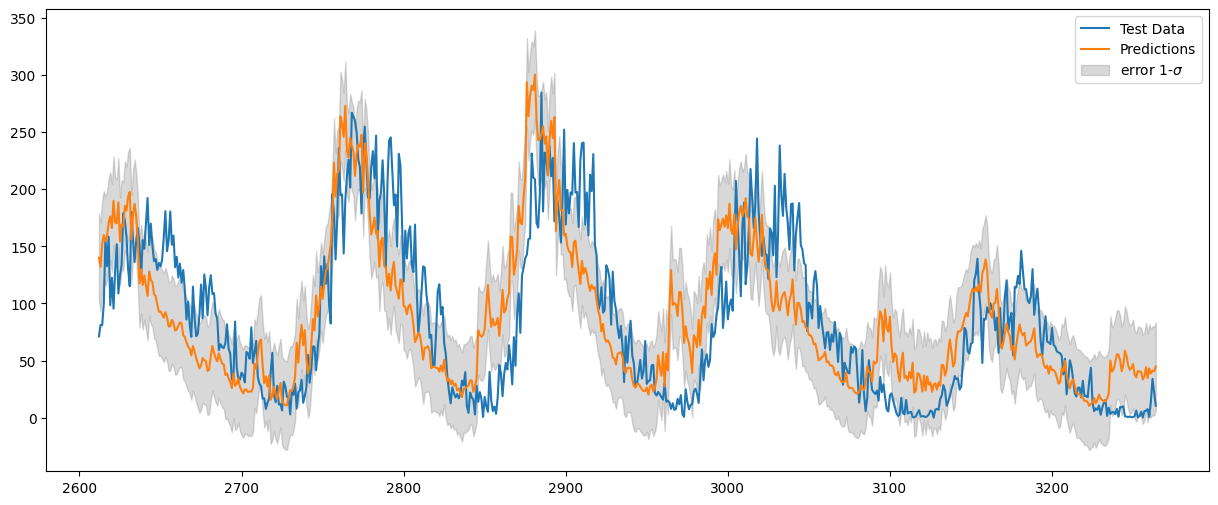

In [55]:
plots_pred(modelwavelet, data, test_data)

## Transfer learning wirh tf.keras.applications

In [135]:
data_train = data_load(ds_train_mnist,augmented=augment_dataTL)
data_test = data_load(ds_test_mnist,shuffle_=False)
for ds,lb in data_train.take(1):
    shaped=list(ds.shape)
shaped

[5, 224, 224, 3]

In [136]:
ds[0].numpy().min(),ds[0].numpy().max()

(0.0, 248.45293)

In [137]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
feature_extractor = ResNet50(input_shape=(224, 224, 3),
                                               include_top=True,
                                               weights='imagenet')

In [138]:
feature_extractor.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_16 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_16[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

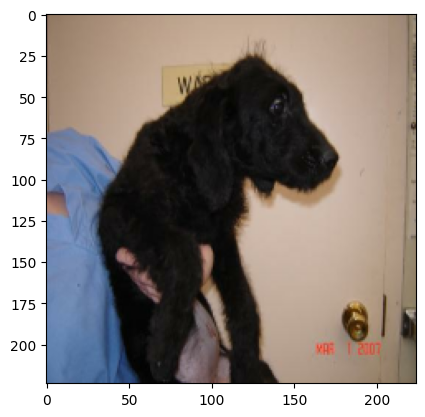

In [139]:
plt.imshow(ds[0].numpy()/255.)

In [142]:
img = preprocess_input(ds[0:1].numpy())
predictions = feature_extractor.predict(img)
decoded_predictions = decode_predictions(predictions, top=3)[0]

1/1 [==============================] - 0s 110ms/step


In [143]:
decoded_predictions

[('n02099267', 'flat-coated_retriever', 0.81947905),
 ('n02111277', 'Newfoundland', 0.049449243),
 ('n02097130', 'giant_schnauzer', 0.035255086)]

In [117]:
feature_extractor.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_14 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_14[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [89]:
for layer in feature_extractor.layers:
    print(layer.name, layer.trainable)

input_11 True
conv1_pad True
conv1_conv True
conv1_bn True
conv1_relu True
pool1_pad True
pool1_pool True
conv2_block1_1_conv True
conv2_block1_1_bn True
conv2_block1_1_relu True
conv2_block1_2_conv True
conv2_block1_2_bn True
conv2_block1_2_relu True
conv2_block1_0_conv True
conv2_block1_3_conv True
conv2_block1_0_bn True
conv2_block1_3_bn True
conv2_block1_add True
conv2_block1_out True
conv2_block2_1_conv True
conv2_block2_1_bn True
conv2_block2_1_relu True
conv2_block2_2_conv True
conv2_block2_2_bn True
conv2_block2_2_relu True
conv2_block2_3_conv True
conv2_block2_3_bn True
conv2_block2_add True
conv2_block2_out True
conv2_block3_1_conv True
conv2_block3_1_bn True
conv2_block3_1_relu True
conv2_block3_2_conv True
conv2_block3_2_bn True
conv2_block3_2_relu True
conv2_block3_3_conv True
conv2_block3_3_bn True
conv2_block3_add True
conv2_block3_out True
conv3_block1_1_conv True
conv3_block1_1_bn True
conv3_block1_1_relu True
conv3_block1_2_conv True
conv3_block1_2_bn True
conv3_block

In [167]:
feature_extractor = ResNet50(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')

In [168]:
feature_extractor.trainable=False
for layer in feature_extractor.layers:
    print(layer.name, layer.trainable)

input_18 False
conv1_pad False
conv1_conv False
conv1_bn False
conv1_relu False
pool1_pad False
pool1_pool False
conv2_block1_1_conv False
conv2_block1_1_bn False
conv2_block1_1_relu False
conv2_block1_2_conv False
conv2_block1_2_bn False
conv2_block1_2_relu False
conv2_block1_0_conv False
conv2_block1_3_conv False
conv2_block1_0_bn False
conv2_block1_3_bn False
conv2_block1_add False
conv2_block1_out False
conv2_block2_1_conv False
conv2_block2_1_bn False
conv2_block2_1_relu False
conv2_block2_2_conv False
conv2_block2_2_bn False
conv2_block2_2_relu False
conv2_block2_3_conv False
conv2_block2_3_bn False
conv2_block2_add False
conv2_block2_out False
conv2_block3_1_conv False
conv2_block3_1_bn False
conv2_block3_1_relu False
conv2_block3_2_conv False
conv2_block3_2_bn False
conv2_block3_2_relu False
conv2_block3_3_conv False
conv2_block3_3_bn False
conv2_block3_add False
conv2_block3_out False
conv3_block1_1_conv False
conv3_block1_1_bn False
conv3_block1_1_relu False
conv3_block1_2_co

In [169]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = feature_extractor(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x=Dense(256,activation='relu')(x)
outputs =Dense(2,activation='softmax')(x)

model_train = tf.keras.Model(inputs=inputs, outputs=outputs)

model_train.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_19 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_2  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_10 (Dense)            (None, 256)               524544    
                                                                 
 dense_11 (Dense)            (None, 2)                 514       
                                                                 
Total params: 24112770 (91.98 MB)
Trainable params: 525058 (2.00 MB)
Non-trainable params: 23587712 (89.98 MB)
______________

In [170]:
model_train.compile(
  optimizer=tf.keras.optimizers.Adam(5e-5),
  loss=tf.keras.losses.CategoricalCrossentropy(),
  metrics=['acc'])

In [171]:
NUM_EPOCHS = 1

history = model_train.fit(data_train,
                    validation_data=data_test,
                    epochs=NUM_EPOCHS,
                    verbose=1)

306/931 [========>.....................] - ETA: 2:20 - loss: 0.6978 - acc: 0.5065

KeyboardInterrupt: 

In [172]:
model_train.evaluate(data_test)

 54/466 [==>...........................] - ETA: 1:33 - loss: 0.6853 - acc: 0.5000

KeyboardInterrupt: 

In [173]:
for idx, layer in enumerate(feature_extractor.layers):
    print(idx, layer.name, layer.trainable)

0 input_18 False
1 conv1_pad False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 pool1_pad False
6 pool1_pool False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_conv False
11 conv2_block1_2_bn False
12 conv2_block1_2_relu False
13 conv2_block1_0_conv False
14 conv2_block1_3_conv False
15 conv2_block1_0_bn False
16 conv2_block1_3_bn False
17 conv2_block1_add False
18 conv2_block1_out False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_conv False
23 conv2_block2_2_bn False
24 conv2_block2_2_relu False
25 conv2_block2_3_conv False
26 conv2_block2_3_bn False
27 conv2_block2_add False
28 conv2_block2_out False
29 conv2_block3_1_conv False
30 conv2_block3_1_bn False
31 conv2_block3_1_relu False
32 conv2_block3_2_conv False
33 conv2_block3_2_bn False
34 conv2_block3_2_relu False
35 conv2_block3_3_conv False
36 conv2_block3_3_bn False
37 conv2_block3_add False
38 conv2_blo

In [177]:
feature_extractor.trainable = True

In [178]:
for layer in feature_extractor.layers[:165]:
    layer.trainable=False

In [179]:
for idx, layer in enumerate(feature_extractor.layers):
    print(idx, layer.name, layer.trainable)

0 input_18 False
1 conv1_pad False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 pool1_pad False
6 pool1_pool False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_conv False
11 conv2_block1_2_bn False
12 conv2_block1_2_relu False
13 conv2_block1_0_conv False
14 conv2_block1_3_conv False
15 conv2_block1_0_bn False
16 conv2_block1_3_bn False
17 conv2_block1_add False
18 conv2_block1_out False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_conv False
23 conv2_block2_2_bn False
24 conv2_block2_2_relu False
25 conv2_block2_3_conv False
26 conv2_block2_3_bn False
27 conv2_block2_add False
28 conv2_block2_out False
29 conv2_block3_1_conv False
30 conv2_block3_1_bn False
31 conv2_block3_1_relu False
32 conv2_block3_2_conv False
33 conv2_block3_2_bn False
34 conv2_block3_2_relu False
35 conv2_block3_3_conv False
36 conv2_block3_3_bn False
37 conv2_block3_add False
38 conv2_blo

In [180]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = feature_extractor(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x=Dense(256,activation='relu')(x)
outputs =Dense(10)(x)

model_train = tf.keras.Model(inputs=inputs, outputs=outputs)

model_train.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_20 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 tf.__operators__.getitem (  (None, 224, 224, 3)       0         
 SlicingOpLambda)                                                
                                                                 
 tf.nn.bias_add (TFOpLambda  (None, 224, 224, 3)       0         
 )                                                               
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_3  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                           